In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Afrin Shamsudheen\Downloads\train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [23]:
df = df.drop(columns=['PoolQC','MiscFeature','Alley','Fence'], errors='ignore')

In [24]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna("None")

C:\Users\Afrin Shamsudheen\AppData\Local\Temp\ipykernel_20728\1935078393.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [25]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [26]:
df['AgeAtSale'] = df['YrSold'] - df['YearBuilt']
df['TotalSF'] = df['GrLivArea'] + df['TotalBsmtSF'] + df['1stFlrSF']

In [27]:
import numpy as np
df['LogSalePrice'] = np.log1p(df['SalePrice'])

In [28]:
features = [
'GrLivArea',
'OverallQual',
'Neighborhood',
'TotalBsmtSF',
'GarageCars',
'YearBuilt',
'AgeAtSale',
'TotalSF'
]

X = df[features]
y = df['LogSalePrice']

In [29]:
X = pd.get_dummies(X, drop_first=True)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 0.16018642704083824


In [33]:
print("Model evaluation completed")
print("Root Mean Squared Error (RMSE):", rmse)

Model evaluation completed
Root Mean Squared Error (RMSE): 0.16018642704083824


In [34]:
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

results.head()

,Actual Price,Predicted Price
892,11.947956,11.835586
1105,12.691584,12.643183
413,11.652696,11.649158
522,11.976666,11.975716
1036,12.661917,12.609804


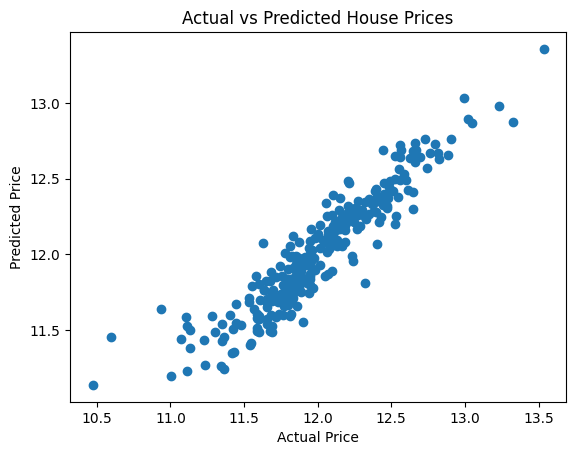

In [35]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [38]:
import joblib

joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']